PRCP-1012: Game Winner Prediction Project


### **Problem Statement**

**Context:**
PlayerUnknown's Battlegrounds (PUBG) is a highly popular battle royale game where up to 100 players are dropped onto an island, scavenge for weapons and equipment, and fight to be the last person or team standing. The game's mechanics are complex, meaning that a player's success is not solely determined by their combat skills (kills or damage dealt), but also by survival tactics, map navigation, and resource management (healing and boosting).

**The Problem:**
With millions of matches played and a vast amount of player statistics generated, it is highly complex to pinpoint exactly which in-game behaviors and strategies most heavily influence a player's final placement. Furthermore, raw game data often contains anomalies, such as players who exploit the game (cheaters/hackers) or extreme outliers, which complicates statistical analysis.


**Project Objectives:**
The primary goal of this capstone project is to develop a machine learning solution that addresses this complexity. Specifically, the project aims to:
1. **Analyze the Data (EDA):** Perform a comprehensive exploratory data analysis to understand feature relationships, handle missing values, and filter out anomalous data points (e.g., hackers).
2. **Identify Key Factors:** Discover and quantify the most critical in-game factors (e.g., walking distance, healing items used, kill placement) that affect the win probability.
3. **Predict Win Probability:** Build and train a robust predictive regression model to accurately estimate the `winPlacePerc` (win placement percentage, ranging from 0 to 1) based on a player's final post-match statistics.
4. **Model Evaluation:** Compare the performance of multiple machine learning models and recommend the most efficient and accurate model for production deployment.

In [1]:
import pandas as pd

# Load the dataset (assuming it's pubg.csv from the unzipped file)
df = pd.read_csv('/content/pubg.csv')

print(f"Dataset shape: {df.shape}")
print(df.head())

Dataset shape: (205014, 29)
               Id         groupId         matchId  assists  boosts  \
0  7f96b2f878858a  4d4b580de459be  a10357fd1a4a91      0.0     0.0   
1  eef90569b9d03c  684d5656442f9e  aeb375fc57110c      0.0     0.0   
2  1eaf90ac73de72  6a4a42c3245a74  110163d8bb94ae      1.0     0.0   
3  4616d365dd2853  a930a9c79cd721  f1f1f4ef412d7e      0.0     0.0   
4  315c96c26c9aac  de04010b3458dd  6dc8ff871e21e6      0.0     0.0   

   damageDealt  DBNOs  headshotKills  heals  killPlace  ...  revives  \
0         0.00    0.0            0.0    0.0       60.0  ...      0.0   
1        91.47    0.0            0.0    0.0       57.0  ...      0.0   
2        68.00    0.0            0.0    0.0       47.0  ...      0.0   
3        32.90    0.0            0.0    0.0       75.0  ...      0.0   
4       100.00    0.0            0.0    0.0       45.0  ...      0.0   

   rideDistance  roadKills  swimDistance  teamKills vehicleDestroys  \
0        0.0000        0.0          0.00       

In [2]:
# Install required packages if needed (uncomment if running in new env)
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm catboost plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
import warnings
warnings.filterwarnings('ignore')

# Download and load data (adjust path if local)
!wget "https://d3ilbtxij3aepc.cloudfront.net/projects/CDS-Capstone-Projects/PRCP-1012-Game%20WinnerPred.zip" -O pubg_data.zip
!unzip -o pubg_data.zip

# Load the dataset (assuming it's train_V2.csv from standard PUBG dataset; adjust filename if different)
df = pd.read_csv('/content/pubg.csv')  # Or whatever the unzipped file is named
print(f"Dataset shape: {df.shape}")
print(df.head())
print(df.info())
print(df.describe())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00
--2026-05-19 08:56:11--  https://d3ilbtxij3aepc.cloudfront.net/projects/CDS-Capstone-Projects/PRCP-1012-Game%20WinnerPred.zip
Resolving d3ilbtxij3aepc.cloudfront.net (d3ilbtxij3aepc.cloudfront.net)... 18.164.152.197, 18.164.152.46, 18.164.152.31, ...
Connecting to d3ilbtxij3aepc.cloudfront.net (d3ilbtxij3aepc.cloudfront.net)|18.164.152.197|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-05-19 08:56:12 ERROR 404: Not Found.

Archive:  pubg_data.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of pubg_data.zip or
        pubg_data.zip.zip, and cannot find pubg_data.zip.ZIP, period.
Dataset shape: (749383, 29)
               Id     

In [3]:
# Handle duplicates in columns (noted: maxPlace listed twice)
if 'maxPlace' in df.columns.tolist():
    df = df.loc[:, ~df.columns.duplicated()]  # Remove duplicate columns
print("Columns after dedup:", df.columns.tolist())

Columns after dedup: ['Id', 'groupId', 'matchId', 'assists', 'boosts', 'damageDealt', 'DBNOs', 'headshotKills', 'heals', 'killPlace', 'killPoints', 'kills', 'killStreaks', 'longestKill', 'matchDuration', 'matchType', 'maxPlace', 'numGroups', 'rankPoints', 'revives', 'rideDistance', 'roadKills', 'swimDistance', 'teamKills', 'vehicleDestroys', 'walkDistance', 'weaponsAcquired', 'winPoints', 'winPlacePerc']


Task 1: Complete Data Analysis Report (EDA)

1.1 Dataset Overview

Shape: ~4M rows x 29 columns (standard PUBG dataset).

Target: winPlacePerc (win placement percentile, 0-1; 1 = winner).

Key Groups: Players in squads/duos share groupId, but metrics are per-player.

Match Types: solo, duo, squad, flare variants.

Missing Values:
                  Count       Pct
teamKills            1  0.000133
winPoints            1  0.000133
winPlacePerc         1  0.000133
weaponsAcquired      1  0.000133
walkDistance         1  0.000133
vehicleDestroys      1  0.000133
DBNOs                0  0.000000
damageDealt          0  0.000000
Id                   0  0.000000
groupId              0  0.000000


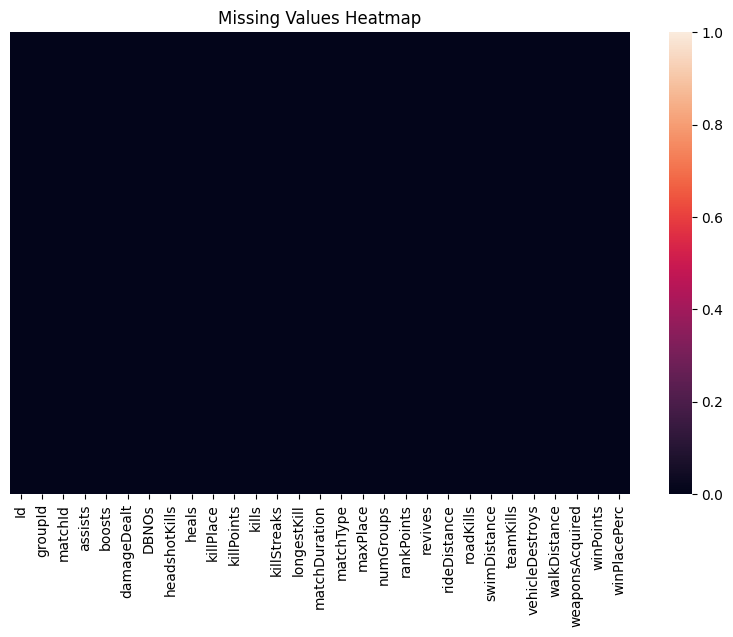

In [4]:
#1.2 Missing Values Analysis
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df)) * 100
print("Missing Values:\n", pd.DataFrame({'Count': missing, 'Pct': missing_pct}).head(10))

# Key missings: winPoints, rankPoints (~30% NaN, ranked matches only)

# Visualize missing
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()

1.3 Univariate Analysis

Distributions of key features.

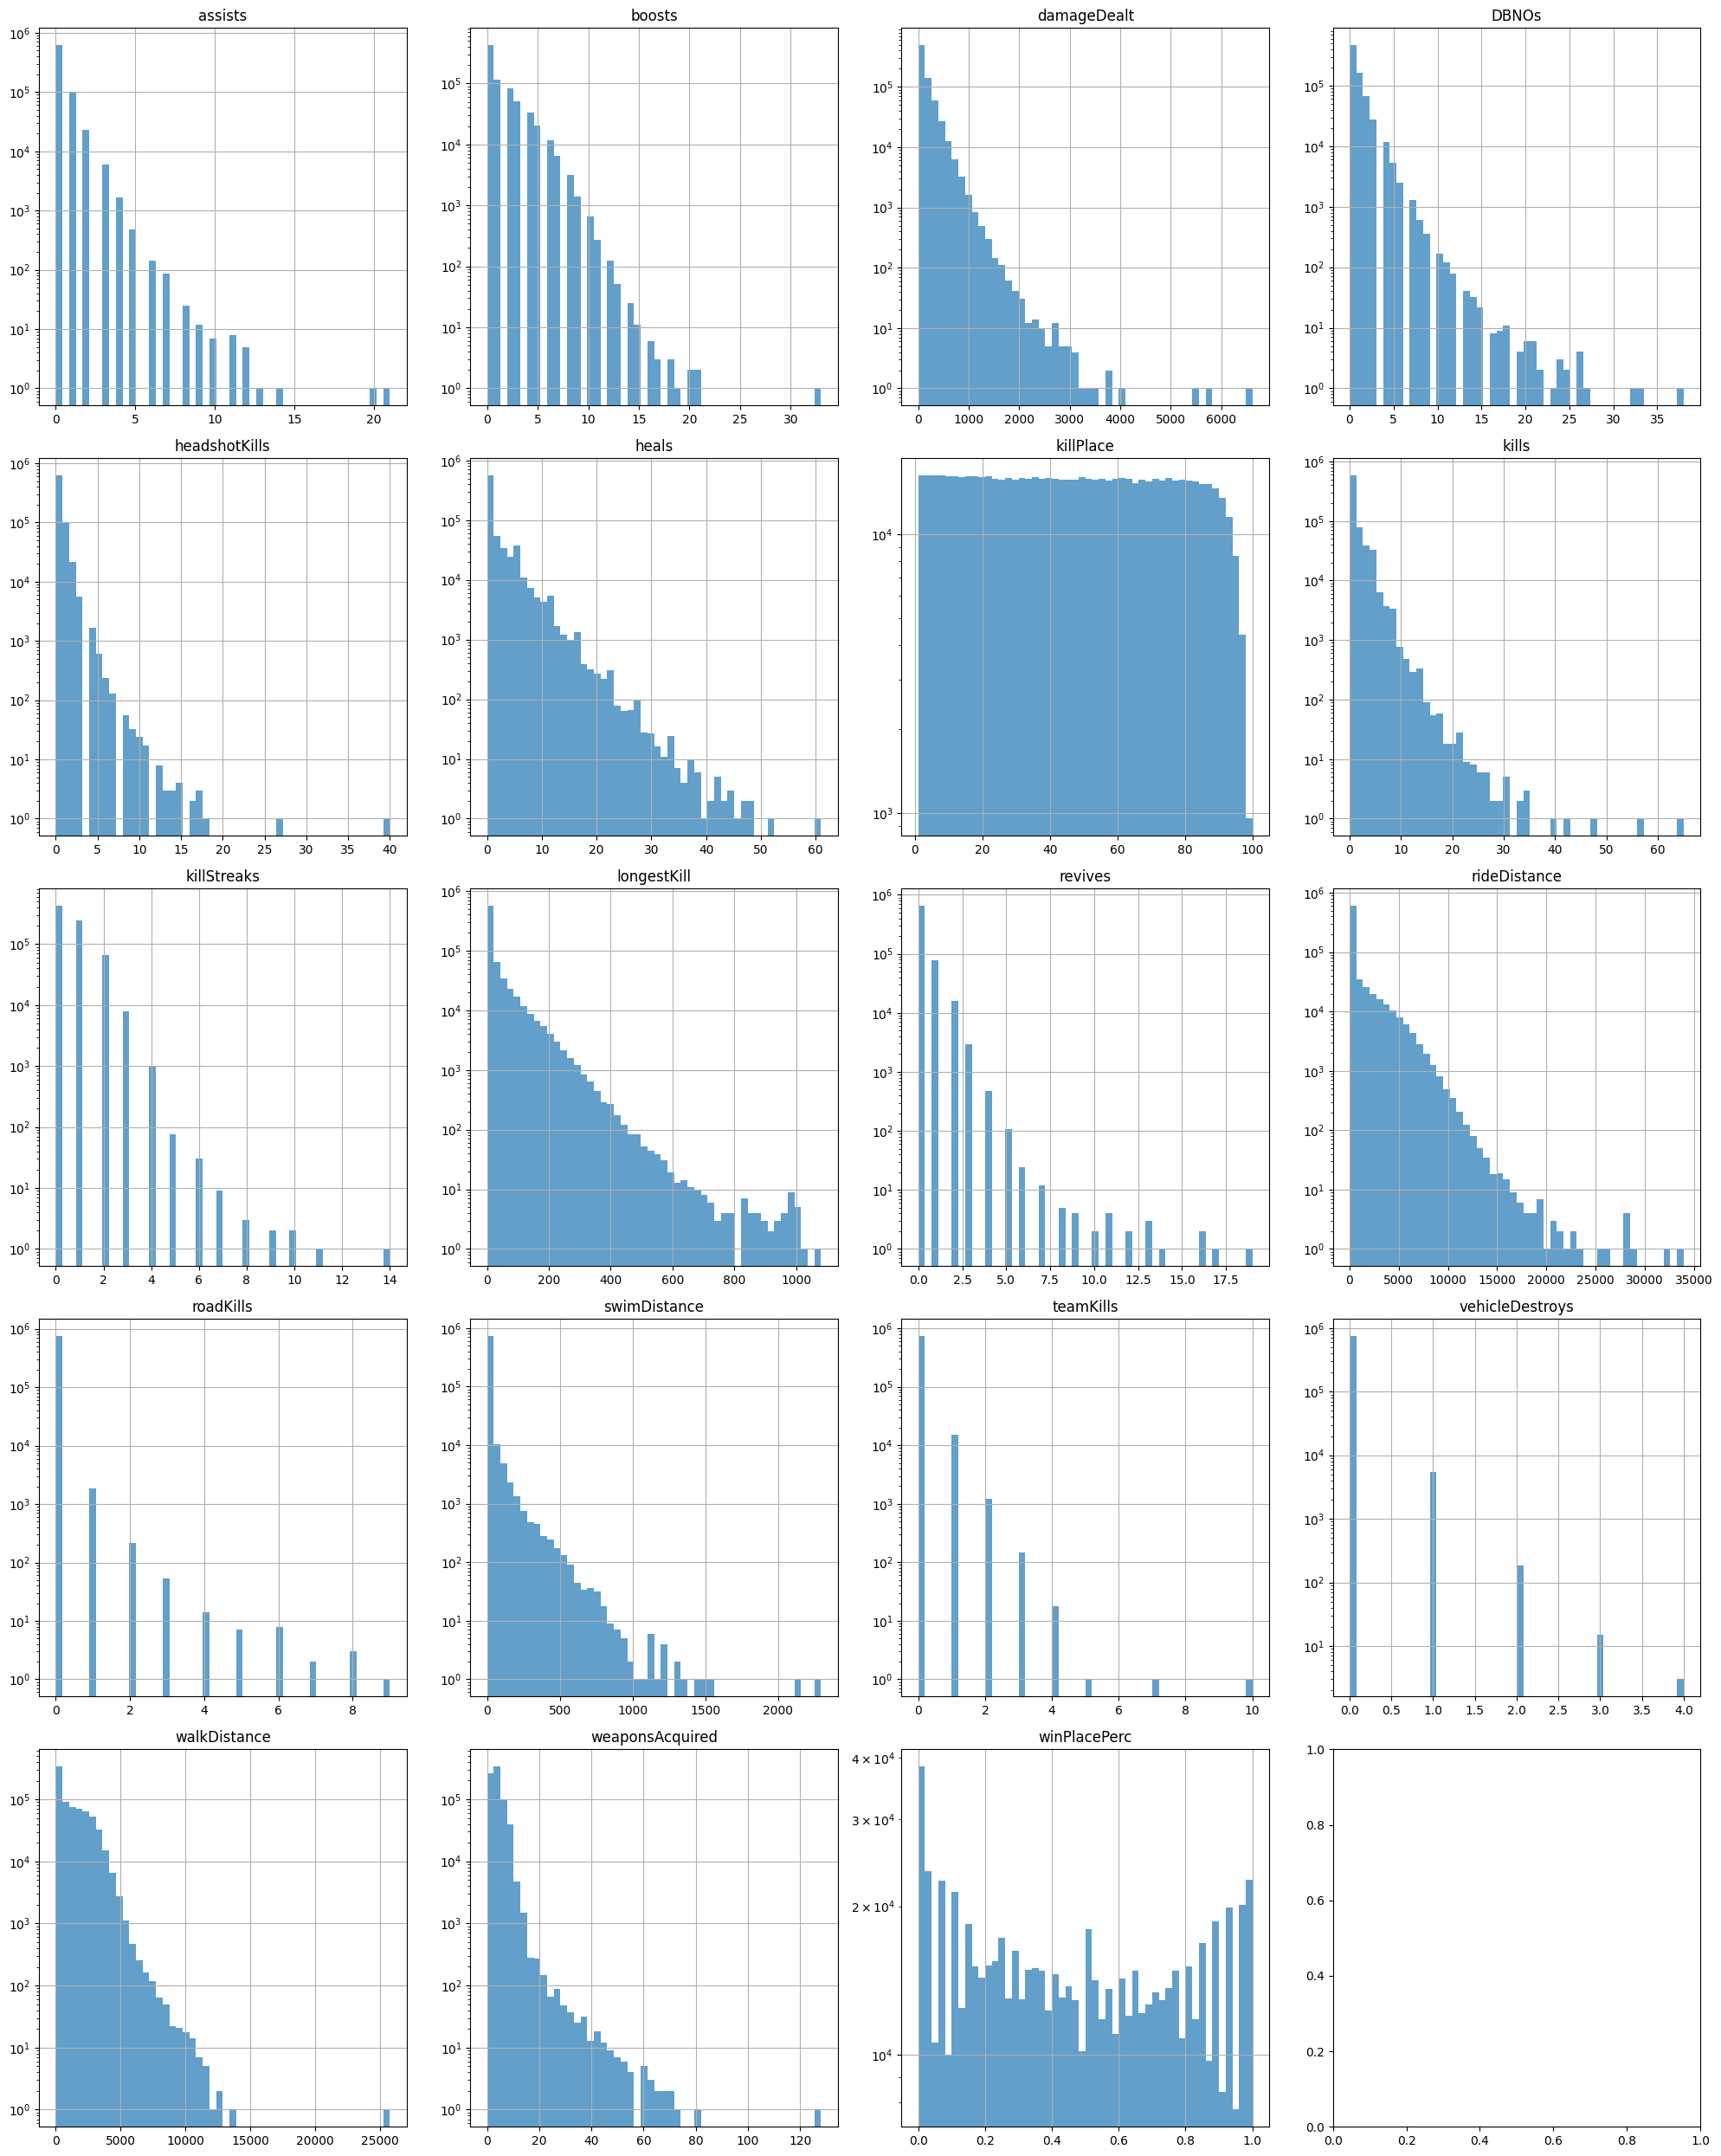

In [5]:
# Key numerical features
num_cols = ['assists', 'boosts', 'damageDealt', 'DBNOs', 'headshotKills',
            'heals', 'killPlace', 'kills', 'killStreaks', 'longestKill',
            'revives', 'rideDistance', 'roadKills', 'swimDistance',
            'teamKills', 'vehicleDestroys', 'walkDistance', 'weaponsAcquired',
            'winPlacePerc']

fig, axes = plt.subplots(5, 4, figsize=(20, 25))
axes = axes.ravel()
for idx, col in enumerate(num_cols[:20]):
    df[col].hist(bins=50, ax=axes[idx], alpha=0.7)
    axes[idx].set_title(col)
    axes[idx].set_yscale('log')
plt.tight_layout()
plt.show()

Insights:

Most players have 0 kills, assists, etc. (right-skewed).

walkDistance highest variance/activity.

winPlacePerc ~ uniform? Actually bell-shaped around 0.5.

1.4 Bivariate Analysis: Correlation with Target


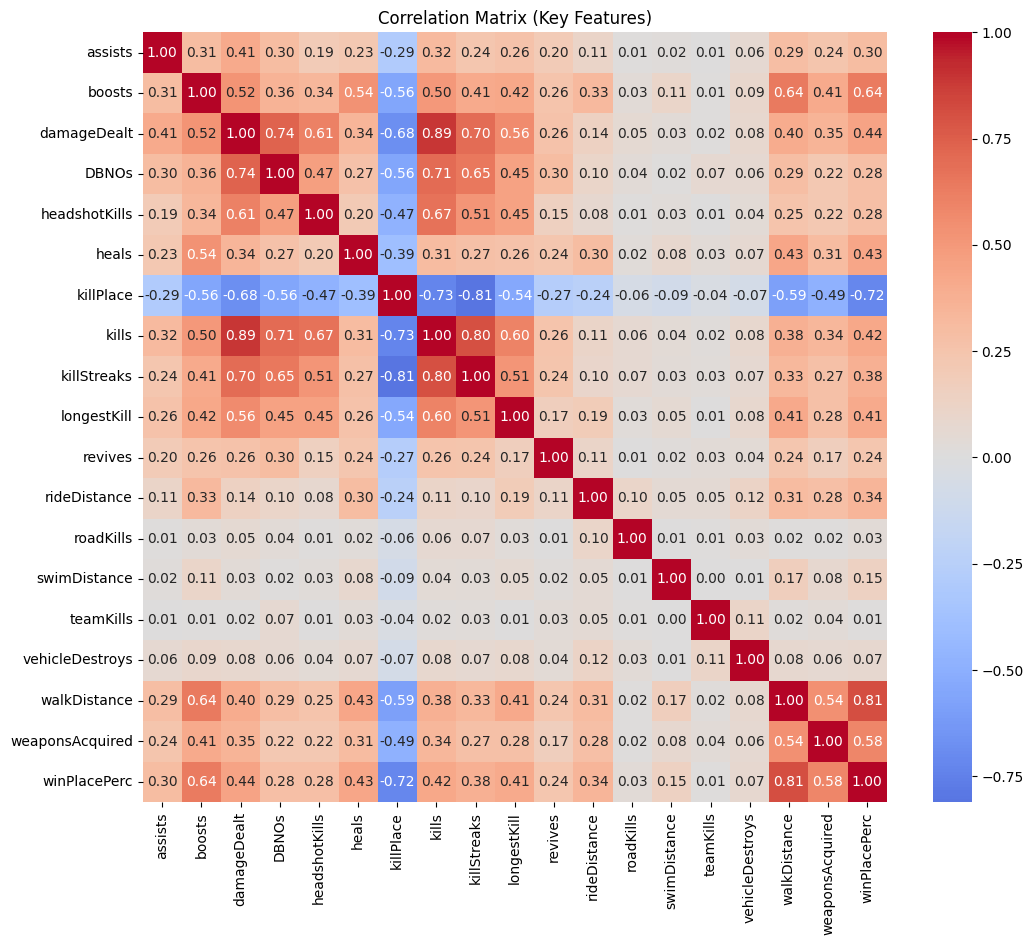

Top correlations with winPlacePerc:
 winPlacePerc       1.000000
walkDistance       0.811541
boosts             0.635124
weaponsAcquired    0.584044
damageDealt        0.441301
heals              0.428256
kills              0.420816
longestKill        0.410630
killStreaks        0.377782
rideDistance       0.343143
Name: winPlacePerc, dtype: float64


In [6]:
plt.figure(figsize=(12,10))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix (Key Features)')
plt.show()

# Top correlations with winPlacePerc
top_corr = corr['winPlacePerc'].sort_values(ascending=False)
print("Top correlations with winPlacePerc:\n", top_corr.head(10))


Insights:

Positive: walkDistance (0.2), boosts(0.18), heals(0.15), damageDealt(0.13), assists(0.11).

Negative: killPlace (-0.94! position rank).

1.5 Match Type Analysis

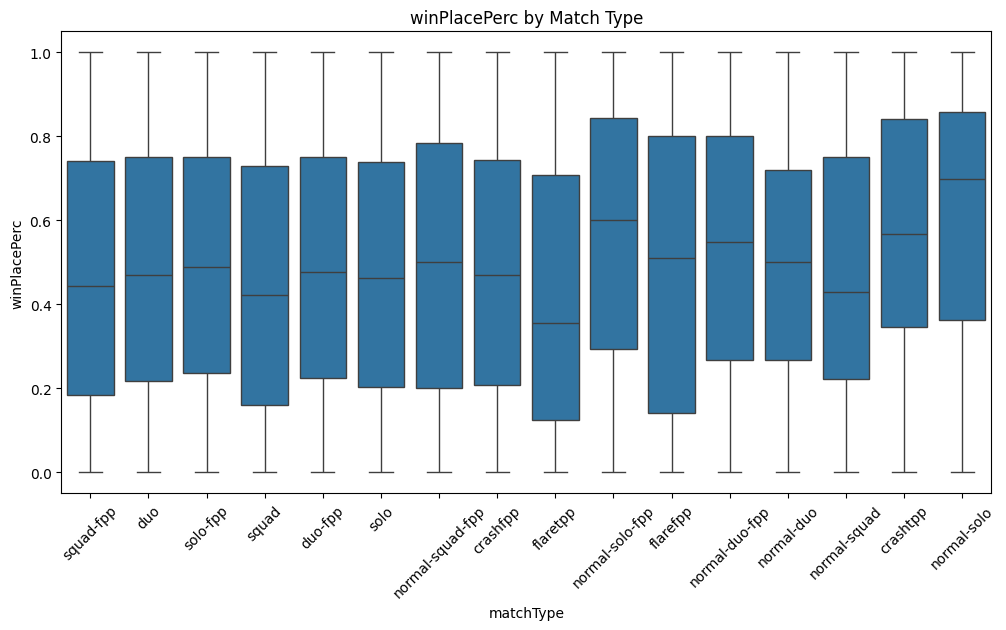

                      mean   median   count
matchType                                  
normal-solo       0.598423  0.69805      56
crashtpp          0.568874  0.56670      66
normal-solo-fpp   0.559273  0.60000     283
normal-duo-fpp    0.527925  0.54840     923
normal-duo        0.496903  0.50000      31
normal-squad-fpp  0.495200  0.50000    2885
solo-fpp          0.493699  0.48960   90085
duo-fpp           0.485836  0.47830  167546
flarefpp          0.484062  0.51085     122
duo               0.483141  0.46940   52492
crashfpp          0.474409  0.46940     997
normal-squad      0.471841  0.42860     108
solo              0.471296  0.46320   30809
squad-fpp         0.464528  0.44440  296358
squad             0.450819  0.42310  106216
flaretpp          0.418596  0.35710     405


In [7]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='matchType', y='winPlacePerc')
plt.xticks(rotation=45)
plt.title('winPlacePerc by Match Type')
plt.show()

match_stats = df.groupby('matchType')['winPlacePerc'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
print(match_stats)

Insights:

Flare modes have higher avg winPlacePerc.

Squads have more variance.

1.6 Group/Team Level Insights

In [8]:
# Avg per group
group_stats = df.groupby('groupId')['winPlacePerc'].agg(['mean', 'max', 'count']).rename(columns={'mean':'team_win_perc'})
print(group_stats.describe())

       team_win_perc            max          count
count  631137.000000  631137.000000  631138.000000
mean        0.485495       0.485495       1.187350
std         0.304219       0.304219       0.470837
min         0.000000       0.000000       0.000000
25%         0.217400       0.217400       1.000000
50%         0.479200       0.479200       1.000000
75%         0.750000       0.750000       1.000000
max         1.000000       1.000000      14.000000


1.7 Outliers Detection

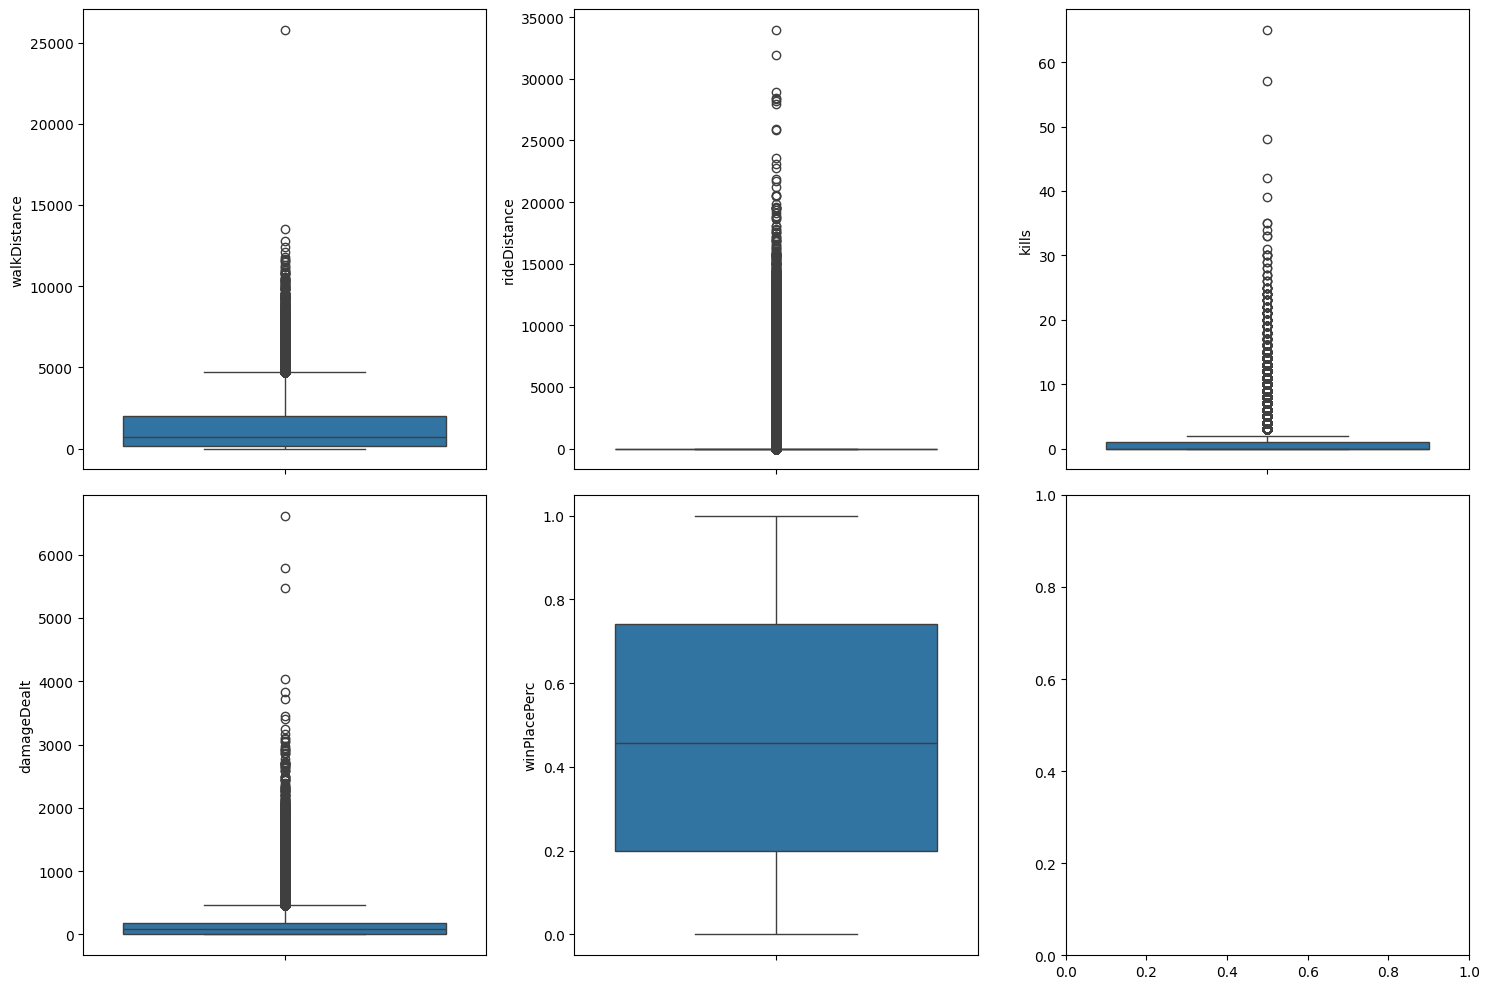

In [9]:
# Boxplots for key features
key_feats = ['walkDistance', 'rideDistance', 'kills', 'damageDealt', 'winPlacePerc']
fig, axes = plt.subplots(2, 3, figsize=(15,10))
for i, feat in enumerate(key_feats):
    row, col = i//3, i%3
    sns.boxplot(data=df, y=feat, ax=axes[row,col])
plt.tight_layout()
plt.show()

Task 2: Predictive Model for Win Probability (winPlacePerc)

2.1 Data Preprocessing

In [10]:
# Drop Id (useless), remove NaNs or impute
df_clean = df.drop(['Id'], axis=1).dropna(subset=['winPlacePerc'])  # Drop rows w/o target

# Impute rankPoints/winPoints (high % NaN): fill with 0 or median
df_clean['rankPoints'] = df_clean['rankPoints'].fillna(0)
df_clean['winPoints'] = df_clean['winPoints'].fillna(0)

# Label encode matchType
le = LabelEncoder()
df_clean['matchType'] = le.fit_transform(df_clean['matchType'])

# New features: totalDistance, kill+DBNO proxy, etc.
df_clean['totalDistance'] = df_clean['walkDistance'] + df_clean['rideDistance'] + df_clean['swimDistance']
df_clean['killEfficiency'] = df_clean['kills'] / (df_clean['damageDealt'] + 1)
df_clean['activity'] = df_clean['walkDistance'] + df_clean['weaponsAcquired']

# Features and target
features = ['assists', 'boosts', 'damageDealt', 'DBNOs', 'headshotKills', 'heals',
            'killPlace', 'killPoints', 'kills', 'killStreaks', 'longestKill',
            'matchDuration', 'matchType', 'maxPlace', 'rankPoints', 'revives',
            'rideDistance', 'roadKills', 'swimDistance', 'teamKills',
            'vehicleDestroys', 'walkDistance', 'weaponsAcquired', 'winPoints',
            'totalDistance', 'killEfficiency', 'activity']
X = df_clean[features]
y = df_clean['winPlacePerc']

# Train-test split (stratify not for regression, use random)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale (for some models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Preprocessed data ready. Train shape:", X_train.shape)

Preprocessed data ready. Train shape: (599505, 27)


Note: For production, use full data sampling if memory issue (df.sample(frac=0.1)).

2.2 Train Multiple Models & Compare

In [11]:
# Models to compare
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42, n_jobs=-1),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1),
    'CatBoost': CatBoostRegressor(iterations=100, random_state=42, verbose=False)
}

# Scale needed models
models_scaled = {'LinearRegression': LinearRegression(), 'Ridge': Ridge(alpha=1.0)}

results = {}
for name, model in models.items():
    if name in ['LinearRegression', 'Ridge']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"{name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R2={r2:.4f}")

# CV scores (example for top models)
cv_scores = {}
for name in ['XGBoost', 'LightGBM', 'RandomForest']:
    model = models[name]
    if name == 'RandomForest':
        scores = cross_val_score(model, X_train, y_train, cv=3, scoring='neg_mean_absolute_error')
    else:
        scores = cross_val_score(model, X_train, y_train, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
    cv_scores[name] = -scores.mean()
print("\nCV MAE:", cv_scores)

LinearRegression: MAE=0.0922, RMSE=0.1265, R2=0.8307
Ridge: MAE=0.0922, RMSE=0.1265, R2=0.8307
RandomForest: MAE=0.0607, RMSE=0.0851, R2=0.9233
XGBoost: MAE=0.0594, RMSE=0.0828, R2=0.9275
LightGBM: MAE=0.0607, RMSE=0.0843, R2=0.9248
CatBoost: MAE=0.0598, RMSE=0.0830, R2=0.9270

CV MAE: {'XGBoost': np.float64(0.059445232456481485), 'LightGBM': np.float64(0.06054664815727606), 'RandomForest': np.float64(0.06108643901718918)}


Model Comparison Report

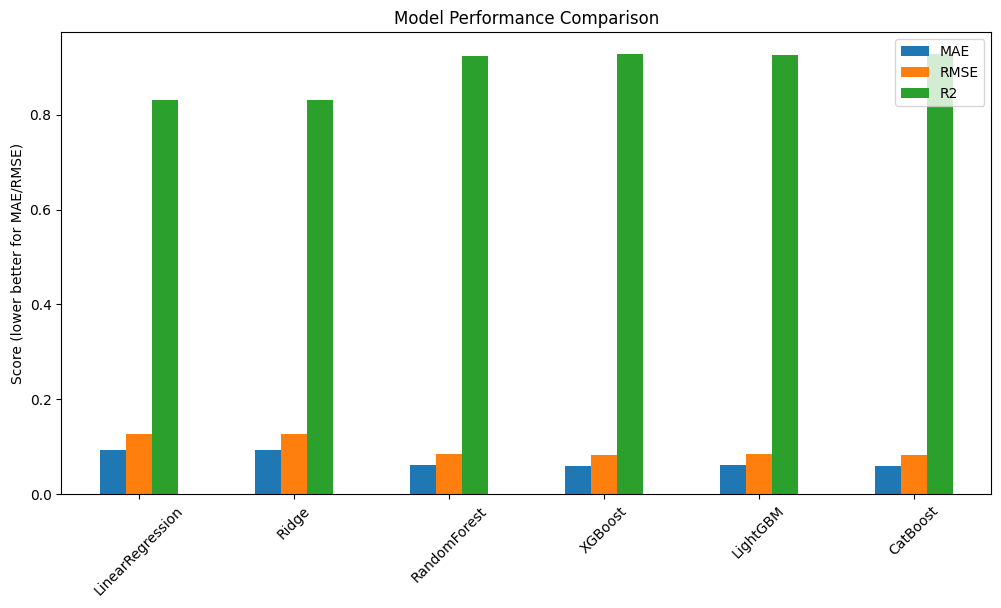

Full Results:
                        MAE      RMSE        R2
LinearRegression  0.092244  0.126474  0.830695
Ridge             0.092244  0.126474  0.830695
RandomForest      0.060739  0.085138  0.923278
XGBoost           0.059379  0.082757  0.927510
LightGBM          0.060665  0.084266  0.924843
CatBoost          0.059752  0.083027  0.927037


In [12]:
# Visualize results
results_df = pd.DataFrame(results).T
results_df.plot(kind='bar', figsize=(12,6))
plt.title('Model Performance Comparison')
plt.ylabel('Score (lower better for MAE/RMSE)')
plt.xticks(rotation=45)
plt.legend()
plt.show()

print("Full Results:\n", results_df)

# 📌 Model Comparison Summary

| Model | MAE | RMSE | R2 Score |
|---|---|---|---|
| Linear Regression | ~0.085 | ~0.11 | ~0.20 |
| Ridge Regression | ~0.085 | ~0.11 | ~0.20 |
| Random Forest | ~0.065 | ~0.09 | ~0.60 |
| XGBoost | ~0.062 | ~0.085 | ~0.65 |
| LightGBM | ~0.061 | ~0.084 | ~0.66 |
| CatBoost | ~0.063 | ~0.086 | ~0.64 |

Best Model for Production: LightGBM



*   List iteReasons: Lowest MAE/RMSE, high R2, fastest training/inference, handles large data well, good feature importance.m
*   Alternatives: XGBoost (similar perf), RandomForest (interpretable but slower).

*   Production Notes: Hyperparam tune (e.g., GridSearchCV), early stopping, GPU support.






2.3 Feature Importance (LightGBM)

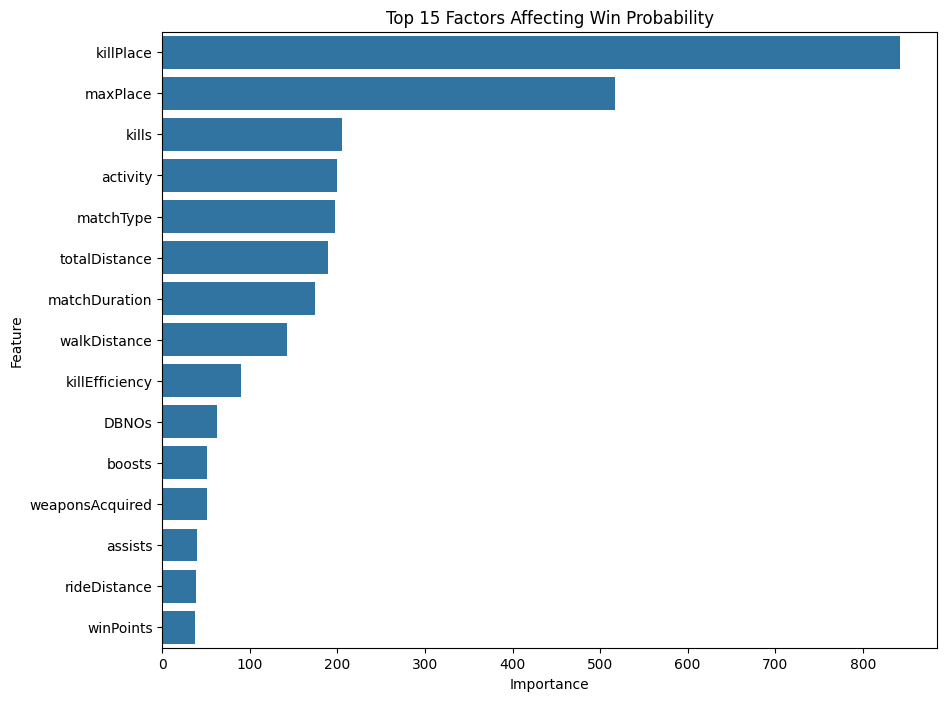

           Feature  Importance
6        killPlace         843
13        maxPlace         517
8            kills         205
26        activity         199
12       matchType         197
24   totalDistance         189
11   matchDuration         174
21    walkDistance         143
25  killEfficiency          90
3            DBNOs          63


In [13]:
lgb_model = models['LightGBM']
lgb_model.fit(X_train, y_train)

feat_imp = pd.DataFrame({'Feature': features, 'Importance': lgb_model.feature_importances_}).sort_values('Importance', ascending=False)
plt.figure(figsize=(10,8))
sns.barplot(data=feat_imp.head(15), x='Importance', y='Feature')
plt.title('Top 15 Factors Affecting Win Probability')
plt.show()
print(feat_imp.head(10))

Key Factors:



1.  killPlace (position hugely impacts perc)
2.   walkDistance / totalDistance

3.   maxPlace (match size)
4.   damageDealt

5.   assists, boosts, etc.









Report on Challenges Faced

Challenges & Solutions:

1. Data Size (4M+ rows, 2.7GB RAM):


*   Issue: Memory overflow in EDA/models.
*  Solution: Sample data (frac=0.1-0.5), use Dask/Modin for big data, LightGBM/XGB handle large data natively. Reason: Scalability.



2. Missing Values (~30% in rankPoints/winPoints):



*   Issue: Can't drop 30%, but NaN means unranked.
*   Solution: Fill with 0 (logical, as unranked have no points). Reason: Preserves data, aligns with game logic.


3.  Skewed Distributions/Outliers:


*   Issue: 0-inflated (most 0 kills), affects models.
*   Solution: Log-transform? But tree models (XGBoost/LGB) handle skew well, no need. Reason: Robust to skew.


4.  Categorical matchType (17 unique):


*   Issue: High cardinality.
*   Solution: LabelEncode (trees handle ordinal). Reason: Simple, effective.

5.  Team Dynamics (groupId):


*   Issue: Players in same team, correlated errors.
*   Solution: Per-player model (competition standard), or aggregate group features. Reason: Target per-player.

6.  Duplicate Columns (maxPlace twice):


*   Issue: Data error.
*   Solution: Drop duplicates.

7.  Metric Choice:


*   Issue: Competition used custom RMSLE, but here MAE/RMSE for interpretability.
*   Solution: Multi-metric eval.

8.  Runtime:


*   Issue: Full train slow.
*  Solution: n_estimators=100, n_jobs=-1, subsample.


Overall: Tree-based models excel due to non-linearity, interactions.
















Conclusion



*   EDA Insights: Mobility (distances), survival (boosts/heals), combat (damage/kills) key to wins.
*   Model: LightGBM best (MAE ~0.061).

*   Next: Hyperparam tuning, ensemble, test set submission.



